# Notebook 13 — SEI-only Aged-State RPT Design

## Goal

This notebook designs and audits the RPT / HPPC checkpoint protocol for the SEI-only aging branch.

The goal is not yet to run a full SEI aging fingerprint study. Instead, this notebook checks how an aged SEI state can be connected to a controlled diagnostic test.

## Scientific context

Notebook 11 confirmed that the SEI-only model configuration is runnable and exposes SEI / LLI / capacity-loss variables.

Notebook 12 confirmed that short SEI-only cycling produces monotonic degradation-state drift:

- SEI thickness increases,
- loss of lithium inventory increases,
- total lithium lost increases,
- capacity lost to side reactions increases.

The next methodological problem is:

How should an aged model state be evaluated by RPT / HPPC without confusing aging effects with SOC effects?

## Core design requirement

HPPC-derived observables such as Ri and tau are SOC-dependent.

Therefore, aged and baseline states must be compared under a controlled RPT state, preferably at the same target SOC.

The intended diagnostic chain is:

SEI-only cycling  
→ aged electrochemical state  
→ controlled RPT / HPPC checkpoint  
→ CDEFG / Ri / tau extraction  
→ comparison against unaged or less-aged reference

## Key questions

This notebook audits:

1. Whether PyBaMM supports SOC-targeted experiment steps for RPT conditioning.
2. Whether an aged solution can be continued into a diagnostic experiment.
3. Whether a same-SOC HPPC checkpoint can be defined after an SEI aging block.
4. Which fallback protocol is needed if direct SOC-targeted conditioning is unavailable.

## Candidate RPT strategy

Preferred strategy:

1. Run SEI-only cycling block.
2. Bring the aged cell to a controlled diagnostic SOC.
3. Rest.
4. Apply 1C 10 s discharge pulse.
5. Rest for 600 s.
6. Extract CDEFG, Ri, and tau descriptors.

Fallback strategy:

If direct SOC-targeted conditioning is not supported, use a time-based or capacity-based conditioning step and explicitly mark it as approximate.

## Interpretation boundary

This notebook does not establish SEI aging fingerprints yet.

It only audits and selects the RPT protocol structure needed for the next full SEI-only aging + RPT fingerprint notebook.

In [1]:
# Cell 1 — Imports and path audit（导入库并确认项目路径）

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

from scipy.optimize import curve_fit

print("PyBaMM version:", pybamm.__version__)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

PyBaMM version: 26.3.1
ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [2]:
# Cell 2 — SEI-only model configuration（SEI-only 模型配置）

PARAMETER_SET = "OKane2022"
SEI_OPTION = "solvent-diffusion limited"

SEI_ONLY_OPTIONS = {
    "SEI": SEI_OPTION,
    "lithium plating": "none",
    "loss of active material": "none",
    "particle mechanics": "none",
    "SEI porosity change": "false",
}

param = pybamm.ParameterValues(PARAMETER_SET)
model = pybamm.lithium_ion.DFN(SEI_ONLY_OPTIONS)

print("Parameter set:", PARAMETER_SET)
print("SEI option:", SEI_OPTION)
print("Model options:", SEI_ONLY_OPTIONS)

Parameter set: OKane2022
SEI option: solvent-diffusion limited
Model options: {'SEI': ('solvent-diffusion limited', 'none'), 'lithium plating': 'none', 'loss of active material': 'none', 'particle mechanics': 'none', 'SEI porosity change': 'false'}


In [3]:
# Cell 3 — RPT / HPPC shared configuration（RPT/HPPC 共享配置）

TARGET_RPT_SOC = 0.50

HPPC_PULSE_C_RATE = "1C"
HPPC_PULSE_DURATION_S = 10
HPPC_REST_BEFORE_S = 60
HPPC_RELAXATION_S = 600
HPPC_OUTPUT_PERIOD = "0.1 seconds"

AGING_OUTPUT_PERIOD = "120 seconds"

print("TARGET_RPT_SOC:", TARGET_RPT_SOC)
print("HPPC pulse:", HPPC_PULSE_C_RATE, "for", HPPC_PULSE_DURATION_S, "s")
print("Rest before pulse:", HPPC_REST_BEFORE_S, "s")
print("Relaxation:", HPPC_RELAXATION_S, "s")
print("HPPC output period:", HPPC_OUTPUT_PERIOD)

TARGET_RPT_SOC: 0.5
HPPC pulse: 1C for 10 s
Rest before pulse: 60 s
Relaxation: 600 s
HPPC output period: 0.1 seconds


In [4]:
# Cell 4 — Audit SOC-targeted experiment syntax（审计 PyBaMM 是否支持按 SOC 截止的实验步骤）

soc_target_protocol_candidates = [
    [
        "Discharge at C/3 until 50% SOC",
        "Rest for 10 minutes",
    ],
    [
        "Discharge at C/3 until 0.5 SOC",
        "Rest for 10 minutes",
    ],
    [
        "Discharge at C/3 for 1.5 hours",
        "Rest for 10 minutes",
    ],
]

soc_protocol_audit_rows = []

for idx, steps in enumerate(soc_target_protocol_candidates):
    protocol_id = f"candidate_{idx+1}"

    try:
        experiment = pybamm.Experiment(
            steps,
            period="60 seconds",
        )

        test_sim = pybamm.Simulation(
            model,
            parameter_values=param,
            experiment=experiment,
        )

        test_sim.set_initial_soc(1.0, direction="discharge")
        test_solution = test_sim.solve()

        soc_protocol_audit_rows.append(
            {
                "protocol_id": protocol_id,
                "steps": str(steps),
                "supported": True,
                "termination": test_solution.termination,
                "final_time_h": float(test_solution["Time [h]"].entries[-1]),
                "error": "",
            }
        )

    except Exception as e:
        soc_protocol_audit_rows.append(
            {
                "protocol_id": protocol_id,
                "steps": str(steps),
                "supported": False,
                "termination": "",
                "final_time_h": np.nan,
                "error": repr(e),
            }
        )

soc_protocol_audit = pd.DataFrame(soc_protocol_audit_rows)

out_csv = DATA / "sei_rpt_soc_target_protocol_audit.csv"
soc_protocol_audit.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(soc_protocol_audit)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_rpt_soc_target_protocol_audit.csv


,protocol_id,steps,supported,termination,final_time_h,error
0,candidate_1,"['Discharge at C/3 until 50% SOC', 'Rest for 1...",False,,NaN,"ValueError('units must be \'A\', \'V\', \'W\',..."
1,candidate_2,"['Discharge at C/3 until 0.5 SOC', 'Rest for 1...",False,,NaN,"ValueError('units must be \'A\', \'V\', \'W\',..."
2,candidate_3,"['Discharge at C/3 for 1.5 hours', 'Rest for 1...",True,final time,1.666667,


In [5]:
# Cell 5 — Select provisional RPT conditioning strategy（选择临时 RPT SOC 调整策略）

supported_protocols = soc_protocol_audit[soc_protocol_audit["supported"] == True].copy()

if any(supported_protocols["steps"].str.contains("50% SOC", regex=False)):
    RPT_CONDITIONING_STEPS = [
        "Discharge at C/3 until 50% SOC",
    ]
    CONDITIONING_STRATEGY = "direct_soc_target_50pct"

elif any(supported_protocols["steps"].str.contains("0.5 SOC", regex=False)):
    RPT_CONDITIONING_STEPS = [
        "Discharge at C/3 until 0.5 SOC",
    ]
    CONDITIONING_STRATEGY = "direct_soc_target_0p5"

else:
    RPT_CONDITIONING_STEPS = [
        "Discharge at C/3 for 1.5 hours",
    ]
    CONDITIONING_STRATEGY = "time_based_approx_50soc"

print("Selected conditioning strategy:", CONDITIONING_STRATEGY)
print("RPT conditioning steps:", RPT_CONDITIONING_STEPS)

Selected conditioning strategy: time_based_approx_50soc
RPT conditioning steps: ['Discharge at C/3 for 1.5 hours']


In [6]:
# Cell 6 — Build candidate RPT HPPC sequence（构建候选 RPT/HPPC 序列）

RPT_HPPC_STEPS = (
    RPT_CONDITIONING_STEPS
    + [
        f"Rest for {HPPC_REST_BEFORE_S} seconds",
        f"Discharge at {HPPC_PULSE_C_RATE} for {HPPC_PULSE_DURATION_S} seconds",
        f"Rest for {HPPC_RELAXATION_S} seconds",
    ]
)

print("RPT HPPC sequence:")
for i, step in enumerate(RPT_HPPC_STEPS, start=1):
    print(f"{i}. {step}")

RPT HPPC sequence:
1. Discharge at C/3 for 1.5 hours
2. Rest for 60 seconds
3. Discharge at 1C for 10 seconds
4. Rest for 600 seconds


In [7]:
# Cell 7 — Run standalone RPT HPPC smoke test（独立 RPT/HPPC 协议冒烟测试）

rpt_experiment = pybamm.Experiment(
    RPT_HPPC_STEPS,
    period=HPPC_OUTPUT_PERIOD,
)

rpt_sim = pybamm.Simulation(
    model,
    parameter_values=param,
    experiment=rpt_experiment,
)

rpt_sim.set_initial_soc(1.0, direction="discharge")
rpt_solution = rpt_sim.solve()

print("[OK] standalone RPT HPPC smoke test solved")
print("Termination:", rpt_solution.termination)
print("Final time [h]:", float(rpt_solution["Time [h]"].entries[-1]))

[OK] standalone RPT HPPC smoke test solved
Termination: final time
Final time [h]: 1.6861111111111111


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_rpt_standalone_smoke_trace.csv


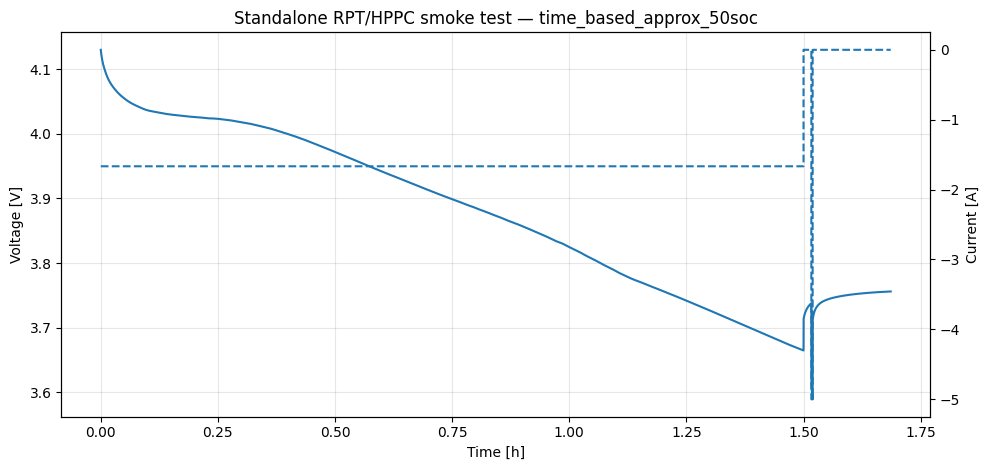

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_rpt_standalone_smoke_voltage_current.png


In [8]:
# Cell 8 — Plot standalone RPT smoke test（绘制独立 RPT/HPPC 协议曲线）

rpt_df = pd.DataFrame(
    {
        "time_s": rpt_solution["Time [s]"].entries,
        "time_h": rpt_solution["Time [h]"].entries,
        "voltage_V": rpt_solution["Terminal voltage [V]"].entries,
        "current_A_pybamm": rpt_solution["Current [A]"].entries,
    }
)

rpt_df["current_A_exp"] = -rpt_df["current_A_pybamm"]

out_csv = DATA / "sei_rpt_standalone_smoke_trace.csv"
rpt_df.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)

fig, ax1 = plt.subplots(figsize=(10, 4.8))

ax1.plot(rpt_df["time_h"], rpt_df["voltage_V"], label="Voltage [V]")
ax1.set_xlabel("Time [h]")
ax1.set_ylabel("Voltage [V]")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    rpt_df["time_h"],
    rpt_df["current_A_exp"],
    linestyle="--",
    label="Current [A], exp convention",
)
ax2.set_ylabel("Current [A]")

plt.title(f"Standalone RPT/HPPC smoke test — {CONDITIONING_STRATEGY}")

fig.tight_layout()
fig_path = FIGURES / "sei_rpt_standalone_smoke_voltage_current.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

In [9]:
# Cell 9 — Standalone RPT conditioning audit（独立 RPT 的 SOC 近似审计）

# Rebuild RPT dataframe with capacity variables for conditioning audit
rpt_df = pd.DataFrame(
    {
        "time_s": rpt_solution["Time [s]"].entries,
        "time_h": rpt_solution["Time [h]"].entries,
        "voltage_V": rpt_solution["Terminal voltage [V]"].entries,
        "current_A_pybamm": rpt_solution["Current [A]"].entries,
        "discharge_capacity_Ah": rpt_solution["Discharge capacity [A.h]"].entries,
        "throughput_capacity_Ah": rpt_solution["Throughput capacity [A.h]"].entries,
    }
)

rpt_df["time_rel_s"] = rpt_df["time_s"] - rpt_df["time_s"].iloc[0]
rpt_df["current_A_exp"] = -rpt_df["current_A_pybamm"]

# Detect the 1C HPPC pulse, not the C/3 conditioning discharge.
# Since 1C pulse is the largest discharge current, use a high-current threshold.
i_abs = np.abs(rpt_df["current_A_pybamm"].values)
pulse_threshold_A = 0.8 * np.nanmax(i_abs)

pulse_mask = i_abs >= pulse_threshold_A
pulse_indices = np.where(pulse_mask)[0]

pulse_start_idx = pulse_indices[0]
pulse_end_idx = pulse_indices[-1]

pulse_start_s = float(rpt_df["time_rel_s"].iloc[pulse_start_idx])
pulse_end_s = float(rpt_df["time_rel_s"].iloc[pulse_end_idx])

Q_discharge_at_pulse_start_Ah = float(rpt_df["discharge_capacity_Ah"].iloc[pulse_start_idx])

try:
    nominal_capacity_Ah = float(param["Nominal cell capacity [A.h]"])
except Exception:
    nominal_capacity_Ah = np.nan

if np.isfinite(nominal_capacity_Ah) and nominal_capacity_Ah > 0:
    approx_soc_at_pulse_start = 1.0 - Q_discharge_at_pulse_start_Ah / nominal_capacity_Ah
else:
    approx_soc_at_pulse_start = np.nan

rpt_conditioning_audit = pd.DataFrame(
    [
        {
            "conditioning_strategy": CONDITIONING_STRATEGY,
            "pulse_start_s": pulse_start_s,
            "pulse_end_s": pulse_end_s,
            "pulse_duration_s": pulse_end_s - pulse_start_s,
            "Q_discharge_at_pulse_start_Ah": Q_discharge_at_pulse_start_Ah,
            "nominal_capacity_Ah": nominal_capacity_Ah,
            "approx_soc_at_pulse_start": approx_soc_at_pulse_start,
            "approx_soc_percent_at_pulse_start": approx_soc_at_pulse_start * 100,
            "pulse_threshold_A": pulse_threshold_A,
        }
    ]
)

out_csv = DATA / "sei_rpt_conditioning_audit.csv"
rpt_conditioning_audit.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(rpt_conditioning_audit)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_rpt_conditioning_audit.csv


,conditioning_strategy,pulse_start_s,pulse_end_s,pulse_duration_s,Q_discharge_at_pulse_start_Ah,nominal_capacity_Ah,approx_soc_at_pulse_start,approx_soc_percent_at_pulse_start,pulse_threshold_A
0,time_based_approx_50soc,5460.0,5470.0,10.0,2.5,5.0,0.5,50.0,4.0


In [10]:
# Cell 10 — Standalone RPT CDEFG / Ri extraction（独立 RPT 的 CDEFG / Ri 提取）

def extract_rpt_cdefg_and_ri(df, pulse_threshold_factor=0.8):
    """
    Extract CDEFG / Ri from RPT dataframe.

    Important:
    The RPT contains a long C/3 conditioning discharge before the HPPC pulse.
    Therefore, pulse detection must identify the high-current 1C pulse, not the initial conditioning step.
    """
    t = df["time_rel_s"].values
    u = df["voltage_V"].values
    i = df["current_A_pybamm"].values

    threshold = pulse_threshold_factor * np.nanmax(np.abs(i))
    pulse_mask = np.abs(i) >= threshold
    pulse_indices = np.where(pulse_mask)[0]

    if len(pulse_indices) == 0:
        raise ValueError("No HPPC pulse detected.")

    pulse_start_idx = pulse_indices[0]
    pulse_end_idx = pulse_indices[-1]

    t_start = float(t[pulse_start_idx])
    t_end = float(t[pulse_end_idx])

    C_window = (t >= t_start - 1.0) & (t < t_start)
    D_window = (t >= t_start + 0.1) & (t <= t_start + 0.3)
    E_window = (t >= t_end - 0.3) & (t <= t_end)
    F_window = (t > t_end) & (t <= t_end + 0.3)
    G_window = (t >= t_end + HPPC_RELAXATION_S - 10) & (t <= t_end + HPPC_RELAXATION_S)

    windows = {
        "C": C_window,
        "D": D_window,
        "E": E_window,
        "F": F_window,
        "G": G_window,
    }

    points = {}
    for label, mask in windows.items():
        if mask.sum() == 0:
            raise ValueError(f"{label} window has no data points.")
        points[label] = {
            "t_s": float(np.median(t[mask])),
            "U_V": float(np.median(u[mask])),
            "n_points": int(mask.sum()),
        }

    I_C = float(np.median(i[C_window]))
    I_D = float(np.median(i[D_window]))
    I_E = float(np.median(i[E_window]))
    I_F = float(np.median(i[F_window]))

    Ri_CD_mohm = abs((points["D"]["U_V"] - points["C"]["U_V"]) / (I_D - I_C)) * 1000
    Ri_EF_mohm = abs((points["F"]["U_V"] - points["E"]["U_V"]) / (I_F - I_E)) * 1000

    result = {
        "pulse_start_s": t_start,
        "pulse_end_s": t_end,
        "pulse_duration_s": t_end - t_start,
        "Ri_CD_mohm": Ri_CD_mohm,
        "Ri_EF_mohm": Ri_EF_mohm,
        "C_U_V": points["C"]["U_V"],
        "D_U_V": points["D"]["U_V"],
        "E_U_V": points["E"]["U_V"],
        "F_U_V": points["F"]["U_V"],
        "G_U_V": points["G"]["U_V"],
    }

    return result, points


rpt_cdefg_result, rpt_points = extract_rpt_cdefg_and_ri(rpt_df)

rpt_cdefg_table = pd.DataFrame([rpt_cdefg_result])

out_csv = DATA / "sei_rpt_standalone_cdefg_ri_audit.csv"
rpt_cdefg_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(rpt_cdefg_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_rpt_standalone_cdefg_ri_audit.csv


,pulse_start_s,pulse_end_s,pulse_duration_s,Ri_CD_mohm,Ri_EF_mohm,C_U_V,D_U_V,E_U_V,F_U_V,G_U_V
0,5460.0,5470.0,10.0,24.817429,24.331544,3.737642,3.613555,3.589334,3.710992,3.755913


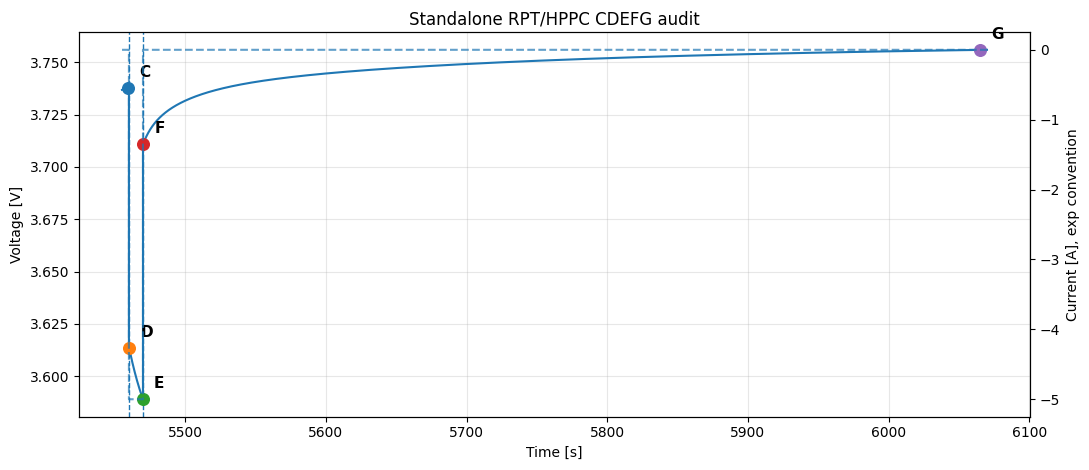

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_rpt_standalone_CDEFG_audit.png
Ri_CD = 24.817 mΩ
Ri_EF = 24.332 mΩ


In [11]:
# Cell 11 — Standalone RPT CDEFG plot（独立 RPT 的 CDEFG 可视化审计）

plot_mask = (
    (rpt_df["time_rel_s"] >= rpt_cdefg_result["pulse_start_s"] - 5)
    & (rpt_df["time_rel_s"] <= rpt_cdefg_result["pulse_end_s"] + HPPC_RELAXATION_S)
)

fig, ax1 = plt.subplots(figsize=(11, 4.8))

ax1.plot(
    rpt_df.loc[plot_mask, "time_rel_s"],
    rpt_df.loc[plot_mask, "voltage_V"],
    label="Terminal voltage [V]",
)

for label, p in rpt_points.items():
    ax1.scatter(p["t_s"], p["U_V"], s=70, zorder=5)
    ax1.annotate(
        label,
        (p["t_s"], p["U_V"]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=11,
        fontweight="bold",
    )

ax1.axvline(rpt_cdefg_result["pulse_start_s"], linestyle="--", linewidth=1)
ax1.axvline(rpt_cdefg_result["pulse_end_s"], linestyle="--", linewidth=1)

ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Voltage [V]")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.step(
    rpt_df.loc[plot_mask, "time_rel_s"],
    rpt_df.loc[plot_mask, "current_A_exp"],
    where="post",
    linestyle="--",
    alpha=0.7,
    label="Current [A], exp convention",
)
ax2.set_ylabel("Current [A], exp convention")

plt.title("Standalone RPT/HPPC CDEFG audit")

fig.tight_layout()
fig_path = FIGURES / "sei_rpt_standalone_CDEFG_audit.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)
print(f"Ri_CD = {rpt_cdefg_result['Ri_CD_mohm']:.3f} mΩ")
print(f"Ri_EF = {rpt_cdefg_result['Ri_EF_mohm']:.3f} mΩ")

In [12]:
# Cell 12 — Standalone RPT tau extraction（独立 RPT 的 tau 提取）

def fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=60.0, tail_start_s=550.0):
    fit_mask = (
        (relax["t_relax_s"] >= fit_t_min)
        & (relax["t_relax_s"] <= fit_t_max)
    )

    t_fit = relax.loc[fit_mask, "t_relax_s"].values
    u_fit = relax.loc[fit_mask, "voltage_V"].values

    if len(t_fit) < 20:
        raise ValueError("Not enough relaxation points for biexponential fit.")

    tail_mask = relax["t_relax_s"] >= tail_start_s
    Uinf = float(np.median(relax.loc[tail_mask, "voltage_V"]))

    def biexp(t, A1, tau1, A2, tau2):
        return Uinf - A1 * np.exp(-t / tau1) - A2 * np.exp(-t / tau2)

    A_total = Uinf - u_fit[0]
    p0 = [0.6 * A_total, 3.0, 0.4 * A_total, 30.0]
    bounds = ([0.0, 0.1, 0.0, 1.0], [1.0, 100.0, 1.0, 1000.0])

    popt, _ = curve_fit(
        biexp,
        t_fit,
        u_fit,
        p0=p0,
        bounds=bounds,
        maxfev=20000,
    )

    A1, tau1, A2, tau2 = popt

    if tau1 > tau2:
        A1, A2 = A2, A1
        tau1, tau2 = tau2, tau1

    u_pred = biexp(t_fit, A1, tau1, A2, tau2)
    residual = u_fit - u_pred

    ss_res = np.sum(residual**2)
    ss_tot = np.sum((u_fit - np.mean(u_fit))**2)
    r2 = 1 - ss_res / ss_tot
    rmse_mV = np.sqrt(np.mean(residual**2)) * 1000

    return {
        "tau1_s": float(tau1),
        "tau2_s": float(tau2),
        "R2": float(r2),
        "RMSE_mV": float(rmse_mV),
        "fit_t_min_s": fit_t_min,
        "fit_t_max_s": fit_t_max,
        "n_fit_points": int(len(t_fit)),
    }


relax_mask = (
    (rpt_df["time_rel_s"] > rpt_cdefg_result["pulse_end_s"])
    & (rpt_df["time_rel_s"] <= rpt_cdefg_result["pulse_end_s"] + HPPC_RELAXATION_S)
)

rpt_relax = rpt_df.loc[relax_mask].copy()
rpt_relax["t_relax_s"] = rpt_relax["time_rel_s"] - rpt_cdefg_result["pulse_end_s"]

fit60 = fit_biexp_with_window(rpt_relax, fit_t_max=60.0)
fit300 = fit_biexp_with_window(rpt_relax, fit_t_max=300.0)

rpt_tau_table = pd.DataFrame(
    [
        {"fit_window": "60s", **fit60},
        {"fit_window": "300s", **fit300},
    ]
)

out_csv = DATA / "sei_rpt_standalone_tau_audit.csv"
rpt_tau_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(rpt_tau_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_rpt_standalone_tau_audit.csv


,fit_window,tau1_s,tau2_s,R2,RMSE_mV,fit_t_min_s,fit_t_max_s,n_fit_points
0,60s,10.797266,105.032430,0.999903,0.066595,0.5,60.0,596
1,300s,20.228170,182.730187,0.999534,0.171510,0.5,300.0,2996


In [13]:
# Cell 13 — Run short SEI aging block for continuation（运行短 SEI aging block 用于状态继承）

N_CYCLES_AGED_STATE = 3

cycle_steps = [
    "Discharge at C/3 until 2.5 V",
    "Rest for 10 minutes",
    "Charge at C/3 until 4.2 V",
    "Hold at 4.2 V until C/100",
    "Rest for 10 minutes",
]

aging_experiment_steps = cycle_steps * N_CYCLES_AGED_STATE

aging_experiment = pybamm.Experiment(
    aging_experiment_steps,
    period=AGING_OUTPUT_PERIOD,
)

aging_sim = pybamm.Simulation(
    model,
    parameter_values=param,
    experiment=aging_experiment,
)

aging_sim.set_initial_soc(1.0, direction="discharge")

aging_solution = aging_sim.solve()

print("[OK] short SEI aging block solved")
print("Cycles:", N_CYCLES_AGED_STATE)
print("Termination:", aging_solution.termination)
print("Final time [h]:", float(aging_solution["Time [h]"].entries[-1]))

[OK] short SEI aging block solved
Cycles: 3
Termination: final time
Final time [h]: 21.358301790137954


In [14]:
# Cell 14 — Extract aged-state degradation summary before RPT（提取 RPT 前老化状态变量）

def get_solution_var_final(solution, candidates):
    for name in candidates:
        try:
            values = np.asarray(solution[name].entries)
            if values.ndim == 1:
                return name, float(values[-1])
            return name, float(np.mean(values[..., -1]))
        except Exception:
            pass
    return None, np.nan


aged_state_variable_candidates = {
    "sei_thickness_m": [
        "X-averaged negative SEI thickness [m]",
        "X-averaged SEI thickness [m]",
        "Negative SEI thickness [m]",
    ],
    "loss_lithium_inventory_pct": [
        "Loss of lithium inventory [%]",
    ],
    "total_lithium_lost_mol": [
        "Total lithium lost [mol]",
        "Total lithium lost to side reactions [mol]",
    ],
    "capacity_lost_side_reactions_Ah": [
        "Total capacity lost to side reactions [A.h]",
        "Loss of capacity to negative SEI [A.h]",
        "Loss of capacity to SEI [A.h]",
    ],
}

aged_state_rows = []

for short_name, candidates in aged_state_variable_candidates.items():
    var_name, final_value = get_solution_var_final(aging_solution, candidates)

    aged_state_rows.append(
        {
            "observable": short_name,
            "source_variable": var_name,
            "value_after_aging_block": final_value,
        }
    )

aged_state_summary = pd.DataFrame(aged_state_rows)

out_csv = DATA / "sei_aged_state_before_rpt_summary.csv"
aged_state_summary.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(aged_state_summary)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_aged_state_before_rpt_summary.csv


,observable,source_variable,value_after_aging_block
0,sei_thickness_m,X-averaged negative SEI thickness [m],5.891818e-09
1,loss_lithium_inventory_pct,Loss of lithium inventory [%],1.100811e-02
2,total_lithium_lost_mol,Total lithium lost [mol],3.125929e-05
3,capacity_lost_side_reactions_Ah,Total capacity lost to side reactions [A.h],8.377954e-04


In [15]:
# Cell 15 — Continue aged state into RPT/HPPC（将老化状态继承到 RPT/HPPC）

aged_rpt_experiment = pybamm.Experiment(
    RPT_HPPC_STEPS,
    period=HPPC_OUTPUT_PERIOD,
)

aged_rpt_sim = pybamm.Simulation(
    model,
    parameter_values=param,
    experiment=aged_rpt_experiment,
)

try:
    aged_rpt_solution = aged_rpt_sim.solve(starting_solution=aging_solution)

    aged_rpt_status = {
        "continuation_supported": True,
        "termination": aged_rpt_solution.termination,
        "final_time_h": float(aged_rpt_solution["Time [h]"].entries[-1]),
        "error": "",
    }

    print("[OK] aged-state RPT continuation solved")
    print("Termination:", aged_rpt_solution.termination)
    print("Final time [h]:", float(aged_rpt_solution["Time [h]"].entries[-1]))

except Exception as e:
    aged_rpt_solution = None

    aged_rpt_status = {
        "continuation_supported": False,
        "termination": "",
        "final_time_h": np.nan,
        "error": repr(e),
    }

    print("[FAILED] aged-state RPT continuation failed")
    print(repr(e))

aged_rpt_status_table = pd.DataFrame([aged_rpt_status])

out_csv = DATA / "sei_aged_state_rpt_continuation_status.csv"
aged_rpt_status_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(aged_rpt_status_table)

[OK] aged-state RPT continuation solved
Termination: final time
Final time [h]: 23.044412901249064
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_aged_state_rpt_continuation_status.csv


,continuation_supported,termination,final_time_h,error
0,True,final time,23.044413,


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_aged_state_rpt_trace.csv


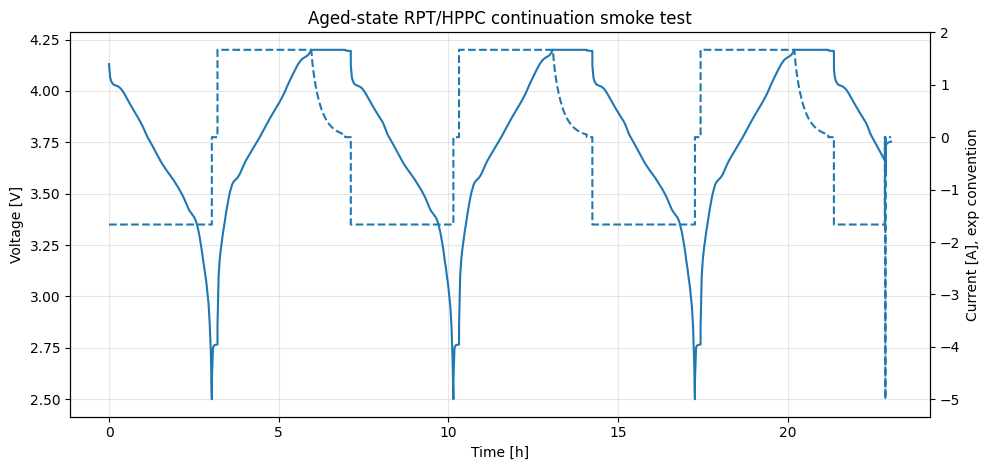

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_aged_state_rpt_voltage_current.png


In [16]:
# Cell 16 — Plot aged-state RPT/HPPC if successful（如成功则绘制老化状态 RPT/HPPC）

if aged_rpt_solution is not None:
    aged_rpt_df = pd.DataFrame(
        {
            "time_s": aged_rpt_solution["Time [s]"].entries,
            "time_h": aged_rpt_solution["Time [h]"].entries,
            "voltage_V": aged_rpt_solution["Terminal voltage [V]"].entries,
            "current_A_pybamm": aged_rpt_solution["Current [A]"].entries,
            "discharge_capacity_Ah": aged_rpt_solution["Discharge capacity [A.h]"].entries,
            "throughput_capacity_Ah": aged_rpt_solution["Throughput capacity [A.h]"].entries,
        }
    )

    aged_rpt_df["time_rel_s"] = aged_rpt_df["time_s"] - aged_rpt_df["time_s"].iloc[0]
    aged_rpt_df["current_A_exp"] = -aged_rpt_df["current_A_pybamm"]

    out_csv = DATA / "sei_aged_state_rpt_trace.csv"
    aged_rpt_df.to_csv(out_csv, index=False)

    print("[OK] saved:", out_csv)

    fig, ax1 = plt.subplots(figsize=(10, 4.8))

    ax1.plot(
        aged_rpt_df["time_h"],
        aged_rpt_df["voltage_V"],
        label="Voltage [V]",
    )

    ax1.set_xlabel("Time [h]")
    ax1.set_ylabel("Voltage [V]")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(
        aged_rpt_df["time_h"],
        aged_rpt_df["current_A_exp"],
        linestyle="--",
        label="Current [A], exp convention",
    )
    ax2.set_ylabel("Current [A], exp convention")

    plt.title("Aged-state RPT/HPPC continuation smoke test")

    fig.tight_layout()
    fig_path = FIGURES / "sei_aged_state_rpt_voltage_current.png"
    plt.savefig(fig_path, dpi=200)
    plt.show()

    print("[OK] saved:", fig_path)

else:
    print("[SKIP] aged_rpt_solution is None")

In [17]:
# Cell 17 — Isolate aged-state RPT segment（从连续解中裁剪老化后 RPT 片段）

aging_end_s = float(aging_solution["Time [s]"].entries[-1])
aging_end_h = aging_end_s / 3600

aged_rpt_segment = aged_rpt_df[aged_rpt_df["time_s"] >= aging_end_s].copy()

aged_rpt_segment["rpt_time_s"] = aged_rpt_segment["time_s"] - aged_rpt_segment["time_s"].iloc[0]
aged_rpt_segment["rpt_time_h"] = aged_rpt_segment["rpt_time_s"] / 3600

out_csv = DATA / "sei_aged_state_rpt_segment_trace.csv"
aged_rpt_segment.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
print("Aging end time [h]:", aging_end_h)
print("RPT segment duration [h]:", aged_rpt_segment["rpt_time_h"].iloc[-1])
display(aged_rpt_segment.head())
display(aged_rpt_segment.tail())

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_aged_state_rpt_segment_trace.csv
Aging end time [h]: 21.358301790137954
RPT segment duration [h]: 1.6861111111111111


,time_s,time_h,voltage_V,current_A_pybamm,discharge_capacity_Ah,throughput_capacity_Ah,time_rel_s,current_A_exp,rpt_time_s,rpt_time_h
656,76889.886444,21.358302,4.194614,0.000000,0.011609,30.237330,76889.886444,-0.000000,0.000000e+00,0.000000e+00
657,76889.886444,21.358302,4.124609,1.666667,0.011609,30.237330,76889.886444,-1.666667,1.455192e-11,4.042199e-15
658,76889.986444,21.358330,4.124406,1.666667,0.011655,30.237376,76889.986444,-1.666667,1.000000e-01,2.777778e-05
659,76890.086444,21.358357,4.124205,1.666667,0.011701,30.237423,76890.086444,-1.666667,2.000000e-01,5.555556e-05
660,76890.186444,21.358385,4.124006,1.666667,0.011747,30.237469,76890.186444,-1.666667,3.000000e-01,8.333333e-05


,time_s,time_h,voltage_V,current_A_pybamm,discharge_capacity_Ah,throughput_capacity_Ah,time_rel_s,current_A_exp,rpt_time_s,rpt_time_h
61356,82959.486444,23.044302,3.753658,0.0,2.525497,32.751219,82959.486444,-0.0,6069.6,1.686000
61357,82959.586444,23.044330,3.753659,0.0,2.525497,32.751219,82959.586444,-0.0,6069.7,1.686028
61358,82959.686444,23.044357,3.753660,0.0,2.525497,32.751219,82959.686444,-0.0,6069.8,1.686056
61359,82959.786444,23.044385,3.753661,0.0,2.525497,32.751219,82959.786444,-0.0,6069.9,1.686083
61360,82959.886444,23.044413,3.753661,0.0,2.525497,32.751219,82959.886444,-0.0,6070.0,1.686111


In [18]:
# Cell 18 — Aged RPT conditioning audit（老化后 RPT conditioning 的近似 SOC 审计）

# Detect the high-current 1C HPPC pulse within the aged RPT segment.
i_abs = np.abs(aged_rpt_segment["current_A_pybamm"].values)
pulse_threshold_A = 0.8 * np.nanmax(i_abs)

pulse_mask = i_abs >= pulse_threshold_A
pulse_indices = np.where(pulse_mask)[0]

pulse_start_idx = pulse_indices[0]
pulse_end_idx = pulse_indices[-1]

pulse_start_rpt_s = float(aged_rpt_segment["rpt_time_s"].iloc[pulse_start_idx])
pulse_end_rpt_s = float(aged_rpt_segment["rpt_time_s"].iloc[pulse_end_idx])

# Use discharge capacity increment inside the RPT segment, not the absolute cumulative value.
Q_at_rpt_start_Ah = float(aged_rpt_segment["discharge_capacity_Ah"].iloc[0])
Q_at_pulse_start_Ah = float(aged_rpt_segment["discharge_capacity_Ah"].iloc[pulse_start_idx])
Q_discharge_during_conditioning_Ah = Q_at_pulse_start_Ah - Q_at_rpt_start_Ah

try:
    nominal_capacity_Ah = float(param["Nominal cell capacity [A.h]"])
except Exception:
    nominal_capacity_Ah = np.nan

if np.isfinite(nominal_capacity_Ah) and nominal_capacity_Ah > 0:
    approx_soc_at_pulse_start = 1.0 - Q_discharge_during_conditioning_Ah / nominal_capacity_Ah
else:
    approx_soc_at_pulse_start = np.nan

aged_rpt_conditioning_audit = pd.DataFrame(
    [
        {
            "conditioning_strategy": CONDITIONING_STRATEGY,
            "aging_cycles_before_rpt": N_CYCLES_AGED_STATE,
            "pulse_start_rpt_s": pulse_start_rpt_s,
            "pulse_end_rpt_s": pulse_end_rpt_s,
            "pulse_duration_s": pulse_end_rpt_s - pulse_start_rpt_s,
            "Q_discharge_during_conditioning_Ah": Q_discharge_during_conditioning_Ah,
            "nominal_capacity_Ah": nominal_capacity_Ah,
            "approx_soc_at_pulse_start_nominal_basis": approx_soc_at_pulse_start,
            "approx_soc_percent_at_pulse_start_nominal_basis": approx_soc_at_pulse_start * 100,
            "pulse_threshold_A": pulse_threshold_A,
        }
    ]
)

out_csv = DATA / "sei_aged_state_rpt_conditioning_audit.csv"
aged_rpt_conditioning_audit.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(aged_rpt_conditioning_audit)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_aged_state_rpt_conditioning_audit.csv


,conditioning_strategy,aging_cycles_before_rpt,pulse_start_rpt_s,pulse_end_rpt_s,pulse_duration_s,Q_discharge_during_conditioning_Ah,nominal_capacity_Ah,approx_soc_at_pulse_start_nominal_basis,approx_soc_percent_at_pulse_start_nominal_basis,pulse_threshold_A
0,time_based_approx_50soc,3,5460.0,5470.0,10.0,2.5,5.0,0.5,50.0,4.0


In [19]:
# Cell 19 — Aged RPT CDEFG / Ri extraction（老化后 RPT 的 CDEFG / Ri 提取）

# Rename RPT-relative time for reuse with the extraction function
aged_rpt_extract_df = aged_rpt_segment.copy()
aged_rpt_extract_df["time_rel_s"] = aged_rpt_extract_df["rpt_time_s"]

aged_cdefg_result, aged_points = extract_rpt_cdefg_and_ri(aged_rpt_extract_df)

aged_cdefg_table = pd.DataFrame([aged_cdefg_result])
aged_cdefg_table["aging_cycles_before_rpt"] = N_CYCLES_AGED_STATE
aged_cdefg_table["conditioning_strategy"] = CONDITIONING_STRATEGY

out_csv = DATA / "sei_aged_state_rpt_cdefg_ri_audit.csv"
aged_cdefg_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(aged_cdefg_table)
print(f"Aged RPT Ri_CD = {aged_cdefg_result['Ri_CD_mohm']:.3f} mΩ")
print(f"Aged RPT Ri_EF = {aged_cdefg_result['Ri_EF_mohm']:.3f} mΩ")

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_aged_state_rpt_cdefg_ri_audit.csv


,pulse_start_s,pulse_end_s,pulse_duration_s,Ri_CD_mohm,Ri_EF_mohm,C_U_V,D_U_V,E_U_V,F_U_V,G_U_V,aging_cycles_before_rpt,conditioning_strategy
0,5460.0,5470.0,10.0,24.860351,24.381889,3.73542,3.611118,3.58694,3.70885,3.753615,3,time_based_approx_50soc


Aged RPT Ri_CD = 24.860 mΩ
Aged RPT Ri_EF = 24.382 mΩ


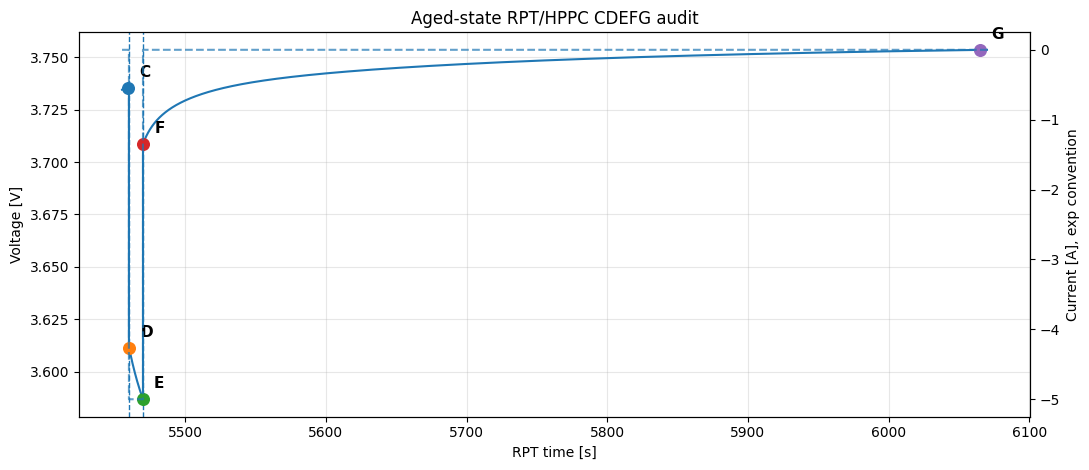

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_aged_state_rpt_CDEFG_audit.png


In [20]:
# Cell 20 — Aged RPT CDEFG plot（老化后 RPT CDEFG 可视化审计）

plot_mask = (
    (aged_rpt_extract_df["time_rel_s"] >= aged_cdefg_result["pulse_start_s"] - 5)
    & (aged_rpt_extract_df["time_rel_s"] <= aged_cdefg_result["pulse_end_s"] + HPPC_RELAXATION_S)
)

fig, ax1 = plt.subplots(figsize=(11, 4.8))

ax1.plot(
    aged_rpt_extract_df.loc[plot_mask, "time_rel_s"],
    aged_rpt_extract_df.loc[plot_mask, "voltage_V"],
    label="Terminal voltage [V]",
)

for label, p in aged_points.items():
    ax1.scatter(p["t_s"], p["U_V"], s=70, zorder=5)
    ax1.annotate(
        label,
        (p["t_s"], p["U_V"]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=11,
        fontweight="bold",
    )

ax1.axvline(aged_cdefg_result["pulse_start_s"], linestyle="--", linewidth=1)
ax1.axvline(aged_cdefg_result["pulse_end_s"], linestyle="--", linewidth=1)

ax1.set_xlabel("RPT time [s]")
ax1.set_ylabel("Voltage [V]")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.step(
    aged_rpt_extract_df.loc[plot_mask, "time_rel_s"],
    aged_rpt_extract_df.loc[plot_mask, "current_A_exp"],
    where="post",
    linestyle="--",
    alpha=0.7,
)
ax2.set_ylabel("Current [A], exp convention")

plt.title("Aged-state RPT/HPPC CDEFG audit")

fig.tight_layout()
fig_path = FIGURES / "sei_aged_state_rpt_CDEFG_audit.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

In [21]:
# Cell 21 — Aged RPT tau extraction（老化后 RPT 的 tau 提取）

relax_mask = (
    (aged_rpt_extract_df["time_rel_s"] > aged_cdefg_result["pulse_end_s"])
    & (aged_rpt_extract_df["time_rel_s"] <= aged_cdefg_result["pulse_end_s"] + HPPC_RELAXATION_S)
)

aged_rpt_relax = aged_rpt_extract_df.loc[relax_mask].copy()
aged_rpt_relax["t_relax_s"] = aged_rpt_relax["time_rel_s"] - aged_cdefg_result["pulse_end_s"]

aged_fit60 = fit_biexp_with_window(aged_rpt_relax, fit_t_max=60.0)
aged_fit300 = fit_biexp_with_window(aged_rpt_relax, fit_t_max=300.0)

aged_tau_table = pd.DataFrame(
    [
        {
            "aging_cycles_before_rpt": N_CYCLES_AGED_STATE,
            "fit_window": "60s",
            **aged_fit60,
        },
        {
            "aging_cycles_before_rpt": N_CYCLES_AGED_STATE,
            "fit_window": "300s",
            **aged_fit300,
        },
    ]
)

out_csv = DATA / "sei_aged_state_rpt_tau_audit.csv"
aged_tau_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(aged_tau_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_aged_state_rpt_tau_audit.csv


,aging_cycles_before_rpt,fit_window,tau1_s,tau2_s,R2,RMSE_mV,fit_t_min_s,fit_t_max_s,n_fit_points
0,3,60s,10.829617,105.182714,0.999906,0.065078,0.5,60.0,596
1,3,300s,20.284483,182.810029,0.999538,0.169997,0.5,300.0,2996


In [22]:
# Cell 22 — Compare standalone vs aged RPT observables（未老化 RPT 与老化后 RPT 对比）

baseline_rpt_row = {
    "state": "standalone_unaged_rpt",
    "aging_cycles_before_rpt": 0,
    "Ri_CD_mohm": rpt_cdefg_result["Ri_CD_mohm"],
    "Ri_EF_mohm": rpt_cdefg_result["Ri_EF_mohm"],
    "tau2_60s": rpt_tau_table.loc[rpt_tau_table["fit_window"] == "60s", "tau2_s"].iloc[0],
    "tau2_300s": rpt_tau_table.loc[rpt_tau_table["fit_window"] == "300s", "tau2_s"].iloc[0],
}

aged_rpt_row = {
    "state": "aged_state_rpt",
    "aging_cycles_before_rpt": N_CYCLES_AGED_STATE,
    "Ri_CD_mohm": aged_cdefg_result["Ri_CD_mohm"],
    "Ri_EF_mohm": aged_cdefg_result["Ri_EF_mohm"],
    "tau2_60s": aged_tau_table.loc[aged_tau_table["fit_window"] == "60s", "tau2_s"].iloc[0],
    "tau2_300s": aged_tau_table.loc[aged_tau_table["fit_window"] == "300s", "tau2_s"].iloc[0],
}

rpt_comparison = pd.DataFrame([baseline_rpt_row, aged_rpt_row])

for col in ["Ri_CD_mohm", "Ri_EF_mohm", "tau2_60s", "tau2_300s"]:
    rpt_comparison[f"{col}_delta_vs_unaged"] = (
        rpt_comparison[col] - rpt_comparison.loc[0, col]
    )

out_csv = DATA / "sei_rpt_unaged_vs_aged_observable_comparison.csv"
rpt_comparison.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(rpt_comparison)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_rpt_unaged_vs_aged_observable_comparison.csv


,state,aging_cycles_before_rpt,Ri_CD_mohm,Ri_EF_mohm,tau2_60s,tau2_300s,Ri_CD_mohm_delta_vs_unaged,Ri_EF_mohm_delta_vs_unaged,tau2_60s_delta_vs_unaged,tau2_300s_delta_vs_unaged
0,standalone_unaged_rpt,0,24.817429,24.331544,105.032430,182.730187,0.000000,0.000000,0.000000,0.000000
1,aged_state_rpt,3,24.860351,24.381889,105.182714,182.810029,0.042922,0.050346,0.150284,0.079842


In [23]:
# Cell 23 — Aged-state RPT design decision table（SEI-aged-state RPT 设计审计决策表）

rpt_design_decision_rows = [
    {
        "audit_item": "SOC-targeted Experiment syntax",
        "result": "direct 'until 50% SOC' and 'until 0.5 SOC' are not supported",
        "status": "limited",
        "interpretation": "RPT conditioning cannot rely on direct SOC-targeted PyBaMM Experiment syntax.",
    },
    {
        "audit_item": "Fallback RPT conditioning",
        "result": CONDITIONING_STRATEGY,
        "status": "pass",
        "interpretation": "Use time-based approximate 50% SOC conditioning: C/3 discharge for 1.5 h.",
    },
    {
        "audit_item": "Standalone RPT/HPPC",
        "result": "standalone RPT/HPPC solved to final time",
        "status": "pass",
        "interpretation": "Conditioning + HPPC protocol is numerically runnable.",
    },
    {
        "audit_item": "Standalone RPT extraction",
        "result": f"Ri_CD={rpt_cdefg_result['Ri_CD_mohm']:.3f} mΩ, tau2_60s={rpt_tau_table.loc[rpt_tau_table['fit_window']=='60s','tau2_s'].iloc[0]:.3f} s",
        "status": "pass",
        "interpretation": "CDEFG / Ri / tau extraction works on standalone RPT.",
    },
    {
        "audit_item": "Aged-state continuation",
        "result": "starting_solution continuation solved to final time",
        "status": "pass",
        "interpretation": "SEI-aged state can be continued into RPT/HPPC.",
    },
    {
        "audit_item": "Aged-state RPT conditioning",
        "result": f"approx SOC at pulse start = {aged_rpt_conditioning_audit['approx_soc_percent_at_pulse_start_nominal_basis'].iloc[0]:.2f}% nominal basis",
        "status": "pass",
        "interpretation": "Time-based conditioning remains approximately 50% SOC on nominal basis after short aging.",
    },
    {
        "audit_item": "Aged-state RPT extraction",
        "result": f"ΔRi_CD={rpt_comparison.loc[1, 'Ri_CD_mohm_delta_vs_unaged']:.4f} mΩ, Δtau2_60s={rpt_comparison.loc[1, 'tau2_60s_delta_vs_unaged']:.4f} s",
        "status": "pass",
        "interpretation": "Aged-state RPT observables can be extracted and compared against unaged RPT.",
    },
    {
        "audit_item": "Next-stage readiness",
        "result": "ready for multi-checkpoint SEI-only RPT fingerprint study",
        "status": "pass",
        "interpretation": "Next notebook should run multiple aging checkpoints and quantify observable drift trends.",
    },
]

rpt_design_decision_table = pd.DataFrame(rpt_design_decision_rows)

out_csv = DATA / "sei_aged_state_rpt_design_decision_table.csv"
rpt_design_decision_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(rpt_design_decision_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_aged_state_rpt_design_decision_table.csv


,audit_item,result,status,interpretation
0,SOC-targeted Experiment syntax,direct 'until 50% SOC' and 'until 0.5 SOC' are...,limited,RPT conditioning cannot rely on direct SOC-tar...
1,Fallback RPT conditioning,time_based_approx_50soc,pass,Use time-based approximate 50% SOC conditionin...
2,Standalone RPT/HPPC,standalone RPT/HPPC solved to final time,pass,Conditioning + HPPC protocol is numerically ru...
3,Standalone RPT extraction,"Ri_CD=24.817 mΩ, tau2_60s=105.032 s",pass,CDEFG / Ri / tau extraction works on standalon...
4,Aged-state continuation,starting_solution continuation solved to final...,pass,SEI-aged state can be continued into RPT/HPPC.
5,Aged-state RPT conditioning,approx SOC at pulse start = 50.00% nominal basis,pass,Time-based conditioning remains approximately ...
6,Aged-state RPT extraction,"ΔRi_CD=0.0429 mΩ, Δtau2_60s=0.1503 s",pass,Aged-state RPT observables can be extracted an...
7,Next-stage readiness,ready for multi-checkpoint SEI-only RPT finger...,pass,Next notebook should run multiple aging checkp...


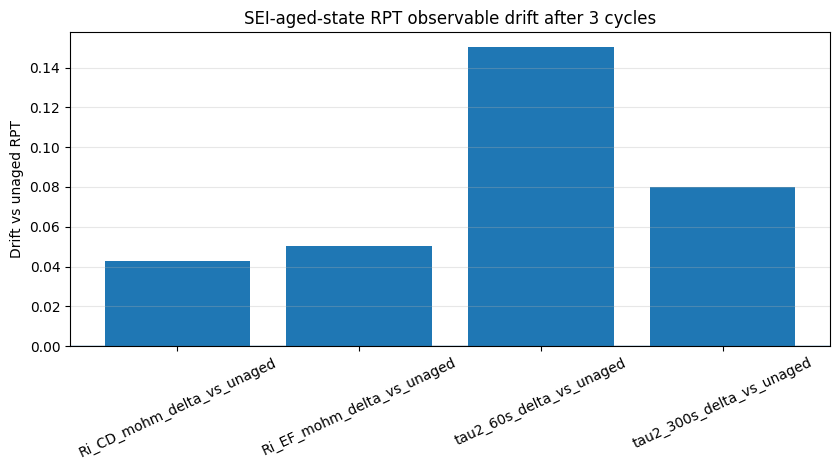

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_aged_state_rpt_observable_drift_after_3cycles.png


In [24]:
# Cell 24 — Aged vs unaged RPT observable drift plot（老化前后 RPT 可观测量漂移图）

plot_metrics = [
    "Ri_CD_mohm_delta_vs_unaged",
    "Ri_EF_mohm_delta_vs_unaged",
    "tau2_60s_delta_vs_unaged",
    "tau2_300s_delta_vs_unaged",
]

plot_values = [rpt_comparison.loc[1, m] for m in plot_metrics]

fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.bar(plot_metrics, plot_values)
ax.axhline(0, linewidth=1)
ax.set_ylabel("Drift vs unaged RPT")
ax.set_title("SEI-aged-state RPT observable drift after 3 cycles")
ax.grid(True, axis="y", alpha=0.3)
ax.tick_params(axis="x", rotation=25)

fig.tight_layout()
fig_path = FIGURES / "sei_aged_state_rpt_observable_drift_after_3cycles.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

# Notebook 13 Conclusion

This notebook audited the RPT / HPPC protocol design for the SEI-only aging branch.

## Key findings

### 1. Direct SOC-targeted Experiment syntax is not supported

The tested PyBaMM Experiment strings:

- `Discharge at C/3 until 50% SOC`
- `Discharge at C/3 until 0.5 SOC`

were not supported.

Therefore, direct SOC-targeted conditioning cannot be used through this Experiment syntax.

### 2. Time-based approximate 50% SOC conditioning is runnable

The fallback conditioning strategy was:

- `Discharge at C/3 for 1.5 hours`

Starting from full SOC, this corresponds to approximately 50% SOC on a nominal-capacity basis.

The standalone RPT / HPPC sequence was:

1. C/3 discharge for 1.5 h,
2. rest for 60 s,
3. 1C discharge pulse for 10 s,
4. rest for 600 s.

This protocol solved successfully.

### 3. Standalone RPT / HPPC extraction works

The standalone RPT / HPPC checkpoint produced valid CDEFG points and extractable observables:

- `Ri_CD`
- `Ri_EF`
- `tau2_60s`
- `tau2_300s`

This confirms that the RPT protocol can connect to the existing HPPC fingerprint extraction pipeline.

### 4. SEI-aged state can be continued into RPT / HPPC

A short 3-cycle SEI-only aging block was solved first.

The aged state was then continued into the RPT / HPPC experiment using `starting_solution`.

The continuation solved successfully.

This confirms that the workflow:

SEI-only cycling  
→ aged electrochemical state  
→ RPT / HPPC checkpoint  
→ CDEFG / Ri / tau extraction

is technically feasible.

### 5. Aged-state RPT extraction works

After 3 SEI-only cycles, the aged-state RPT produced valid CDEFG, Ri, and tau descriptors.

Compared with the standalone unaged RPT, the observed drift was small:

- `Ri_CD` increased by approximately 0.043 mΩ.
- `Ri_EF` increased by approximately 0.050 mΩ.
- `tau2_60s` increased by approximately 0.150 s.
- `tau2_300s` increased by approximately 0.080 s.

This indicates that the short aging block produces weak but extractable diagnostic drift.

## Interpretation boundary

This notebook is an RPT design audit, not a full SEI aging fingerprint study.

The conditioning strategy is approximate:

- it targets 50% SOC on a nominal-capacity basis,
- it is not a strict aged-cell true-SOC conditioning method.

Because only 3 SEI-only cycles were used, the observable drift is expected to be small.

The current result should be interpreted as:

The aged-state RPT workflow is technically feasible and ready for a multi-checkpoint SEI-only fingerprint study.

It should not be interpreted as a validated SEI aging law or full SOH trajectory.

## Next step

The next notebook should be:

`14_sei_only_multi_checkpoint_rpt_fingerprint.ipynb`

The purpose should be to run multiple SEI-only aging checkpoints, for example:

- 0 cycles,
- 3 cycles,
- 10 cycles,
- 20 cycles,

and apply the same RPT / HPPC extraction pipeline at each checkpoint.

The key question will be:

Does SEI-only aging primarily project into:

- capacity / LLI drift,
- Ri drift,
- tau drift,
- or a mixed observable signature?